# 4. Loss Functions
---
A **loss function** (also called a cost function) measures **how wrong** your model's predictions are.  
The goal of training is to **minimize this number**.


A loss function is a type of objective function, which in the context of data science refers to any function whose minimization or maximization represents the objective of model training. The term “loss function,” which is usually synonymous with cost function or error function, refers specifically to situations where minimization is the training objective for a machine learning model.

In simple terms, a loss function tracks the degree of error in an artificial intelligence (AI) model's outputs. It does so by quantifying the difference (“loss”) between a predicted value—that is, the model’s output—for a given input and the actual value or ground truth. If a model’s predictions are accurate, the loss is small. If its predictions are inaccurate, the loss is large.

## 4.1 What is a Loss Function?

During training:
1. Model makes a prediction $\hat{y}$
2. We compare $\hat{y}$ to the true label $y$
3. Loss function returns a **single number** quantifying the error
4. We use this number to update the weights (backprop)

> 🎯 **Goal:** Find weights $W$ that minimize $L(y, \hat{y})$

The choice of loss function depends on the **task type**.


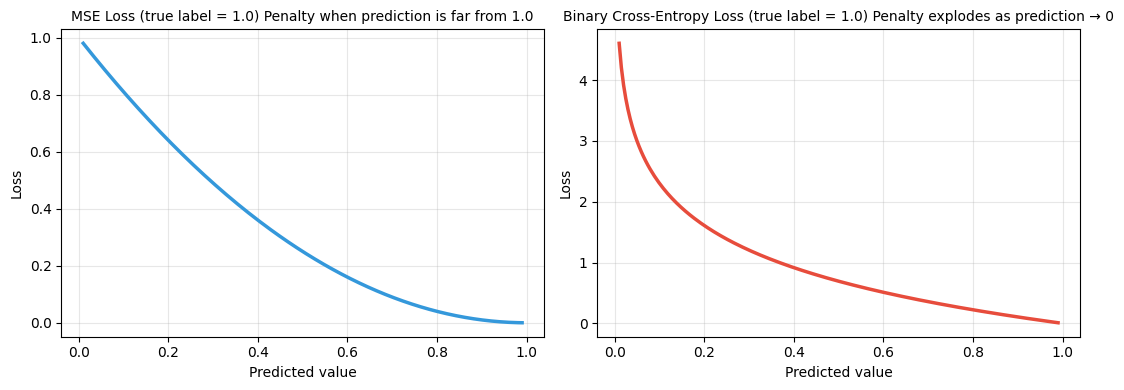

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# True label
y_true = 1.0

# Range of predictions
y_pred = np.linspace(0.01, 0.99, 200)

# MSE
mse = (y_true - y_pred) ** 2

# Binary Cross-Entropy
bce = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(y_pred, mse, color='#3498DB', lw=2.5)
axes[0].set_title("MSE Loss (true label = 1.0) Penalty when prediction is far from 1.0", fontsize=10)
axes[0].set_xlabel("Predicted value"); axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(y_pred, bce, color='#E74C3C', lw=2.5)
axes[1].set_title("Binary Cross-Entropy Loss (true label = 1.0) Penalty explodes as prediction → 0", fontsize=10)
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4.2 Mean Squared Error (MSE) — For Regression

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

✅ Smooth gradient everywhere  
✅ Penalizes large errors more (squared)  
❌ Sensitive to outliers  

**Use:** Regression tasks (predicting a continuous value like house price, temperature).


Good predictions: MSE = 0.0175
Bad predictions:  MSE = 6.5000


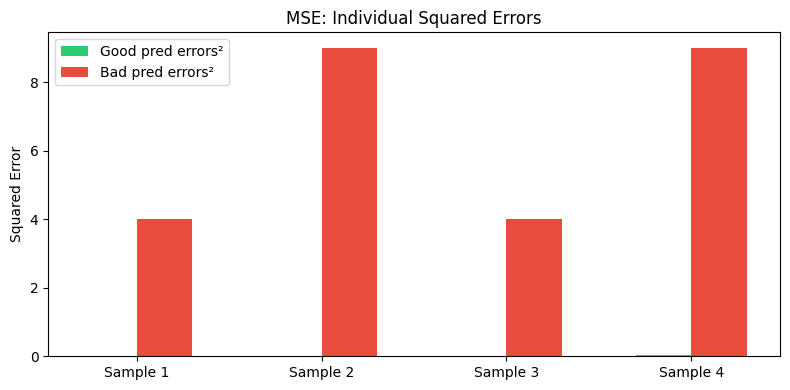

In [2]:
# MSE in action
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Batch of predictions vs true values
y_true = np.array([3.0, 5.0, 2.5, 7.0])
y_pred_good = np.array([3.1, 4.9, 2.4, 7.2])
y_pred_bad  = np.array([1.0, 8.0, 0.5, 4.0])

print(f"Good predictions: MSE = {mse_loss(y_true, y_pred_good):.4f}")
print(f"Bad predictions:  MSE = {mse_loss(y_true, y_pred_bad):.4f}")

# Show individual errors
fig, ax = plt.subplots(figsize=(8, 4))
x_idx = np.arange(4)
ax.bar(x_idx - 0.15, (y_true - y_pred_good)**2, 0.3, label='Good pred errors²', color='#2ECC71')
ax.bar(x_idx + 0.15, (y_true - y_pred_bad)**2,  0.3, label='Bad pred errors²',  color='#E74C3C')
ax.set_xticks(x_idx); ax.set_xticklabels([f'Sample {i+1}' for i in range(4)])
ax.set_ylabel("Squared Error"); ax.set_title("MSE: Individual Squared Errors")
ax.legend(); plt.tight_layout(); plt.show()


## 4.3 Binary Cross-Entropy — For Binary Classification

$$\text{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

Where $\hat{y}_i \in (0, 1)$ is the predicted **probability**.

✅ Designed for probabilities  
✅ Strongly penalizes **confident wrong answers** (if model says 99% but answer is 0 → huge loss)  
✅ Works with sigmoid output  

**Use:** Binary classification (spam/not spam, cat/not cat).


In [3]:
# Binary Cross-Entropy
def binary_cross_entropy(y_true, y_pred, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1-eps)  # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

print("=== Binary Cross-Entropy Examples ===")
cases = [
    ("Correct & confident",    1, 0.95),
    ("Correct & uncertain",    1, 0.55),
    ("Wrong & uncertain",      1, 0.45),
    ("Wrong & very confident", 1, 0.02),
]
for desc, y, yhat in cases:
    loss = binary_cross_entropy(np.array([y]), np.array([yhat]))
    print(f"  {desc:<30} y={y}, ŷ={yhat:.2f} → loss = {loss:.4f}")


=== Binary Cross-Entropy Examples ===
  Correct & confident            y=1, ŷ=0.95 → loss = 0.0513
  Correct & uncertain            y=1, ŷ=0.55 → loss = 0.5978
  Wrong & uncertain              y=1, ŷ=0.45 → loss = 0.7985
  Wrong & very confident         y=1, ŷ=0.02 → loss = 3.9120


## 4.4 Categorical Cross-Entropy — For Multi-class Classification

$$\text{CCE} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

Where $y_c$ is 1 for the true class and 0 elsewhere (one-hot), and $\hat{y}_c$ is the predicted probability from **softmax**.

**Use:** Multi-class classification (digit recognition, image classification).


In [4]:
# Categorical Cross-Entropy
def softmax(x):
    e_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e_x / e_x.sum()

def categorical_cross_entropy(y_true_onehot, logits):
    probs = softmax(logits)
    return -np.sum(y_true_onehot * np.log(probs + 1e-8))

# 3-class example (e.g., cat / dog / bird)
y_true = np.array([0, 1, 0])   # true class: dog (index 1)

logits_correct = np.array([0.1, 3.0, 0.5])   # model is confident about dog
logits_wrong   = np.array([2.5, 0.5, 1.0])   # model thinks it's a cat

print("True class: dog (index 1)")
print(f"Good logits softmax: {np.round(softmax(logits_correct), 3)}")
print(f"  → CCE loss = {categorical_cross_entropy(y_true, logits_correct):.4f}")
print()
print(f"Bad logits softmax:  {np.round(softmax(logits_wrong), 3)}")
print(f"  → CCE loss = {categorical_cross_entropy(y_true, logits_wrong):.4f}")


True class: dog (index 1)
Good logits softmax: [0.048 0.879 0.072]
  → CCE loss = 0.1285

Bad logits softmax:  [0.736 0.1   0.164]
  → CCE loss = 2.3064


## 4.5 Choosing the Right Loss Function

| Task | Output Activation | Loss Function |
|---|---|---|
| Regression | Linear (none) | MSE or MAE |
| Binary Classification | Sigmoid | Binary Cross-Entropy |
| Multi-class Classification | Softmax | Categorical Cross-Entropy |
| Multi-label Classification | Sigmoid per class | Binary Cross-Entropy |


## ✏️ Exercises

Why do we use cross-entropy instead of MSE for classification? *Hint: think about the gradient when the model is confidently wrong.*
